# Damaged 2D truss with linear bar elements
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/meyer-nils/torch-fem/blob/main/examples/basic/truss/damage_2D.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/meyer-nils/torch-fem/main?labpath=examples/basic/truss/damage_2D.ipynb)

A damaging truss with ten nodes and 20 rods, loaded and unloaded again.

In [1]:
import matplotlib.pyplot as plt
import torch

from torchfem import Truss
from torchfem.materials import IsotropicDamage1D

torch.set_default_dtype(torch.float64)

## Material model

We define an isotropic damage model with linear strain softening. A bar is elastic up to a strain of $\varepsilon_0$, from where the damage grows linearly to $D=1$ at $\varepsilon_f$. The damage is irreversible, so a bar that has damaged unloads towards the origin with the degraded stiffness $(1-D)E$ rather than the original one.

In [2]:
# Create material
E = 1000.0
eps_0 = 0.015
eps_f = 0.2


# Damage evolution law for linear strain softening
def d(kappa, cl):
    return torch.clamp((kappa - eps_0) / (eps_f - eps_0), 0.0, 1.0)


# Derivative of the damage evolution law
def d_prime(kappa, cl):
    inside = (kappa > eps_0) & (kappa < eps_f)
    return torch.where(
        inside, torch.full_like(kappa, 1.0 / (eps_f - eps_0)), 0.0 * kappa
    )


material = IsotropicDamage1D(E, d, d_prime, "rankine")

## Model setup

In [3]:
n1 = torch.linspace(0.0, 4.0, 5)
n2 = torch.linspace(0.0, 1.0, 2)
n1, n2 = torch.stack(torch.meshgrid(n1, n2, indexing="xy"))
nodes = torch.stack([n1.ravel(), n2.ravel()], dim=1)

elements = torch.tensor(
    [
        [0, 1],
        [1, 2],
        [2, 3],
        [3, 4],
        [5, 6],
        [6, 7],
        [7, 8],
        [8, 9],
        [1, 5],
        [0, 6],
        [2, 6],
        [1, 7],
        [3, 7],
        [2, 8],
        [4, 8],
        [3, 9],
        [1, 6],
        [2, 7],
        [3, 8],
        [4, 9],
    ]
)

# Create truss
truss = Truss(nodes, elements, material)

# Set boundary conditions
truss.forces[4, 1] = -12.0
truss.constraints[0, 0] = True
truss.constraints[0, 1] = True
truss.constraints[5, 0] = True

## Solve
The load is ramped up and back down again, so that the unloading branch becomes visible.

In [4]:
# Solve
increments = torch.cat((torch.linspace(0.0, 1.0, 21), torch.linspace(1.0, 0.01, 21)))
u, f, σ, F, α = truss.solve(increments=increments, return_intermediate=True)

## Postprocessing

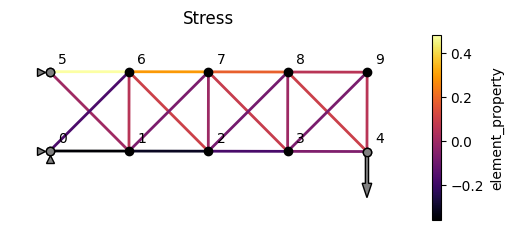

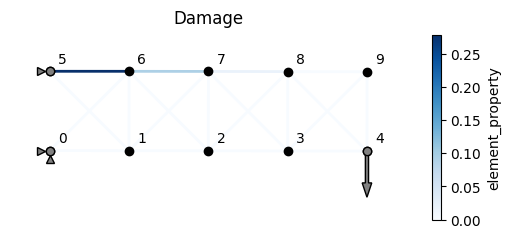

In [5]:
# Plot the deformed truss with stresses
truss.plot(u=u[-1], element_property=σ[-1], title="Stress", cmap="inferno")

# Plot the deformed truss with damage
truss.plot(u=u[-1], element_property=α[-1, :, 1], title="Damage", cmap="Blues")

The most damaged bar traces the softening envelope 
$$
    \sigma = (1-D(\varepsilon)) E \varepsilon
$$ 
while it is loaded. On unloading the damage is frozen, so the bar follows a straight secant back to the origin.

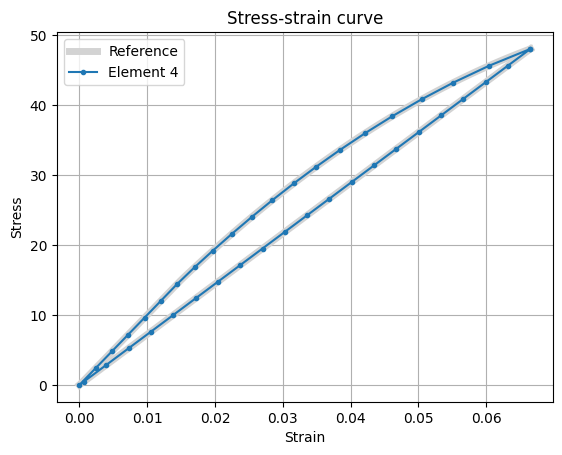

In [6]:
ε = F - 1.0
worst = α[-1, :, 1].argmax()

# Softening envelope and the secant of the damaged bar
ε_env = torch.linspace(0.0, ε[:, worst].max(), 100)
σ_env = (1.0 - d(ε_env, None)) * E * ε_env
D_max = α[-1, worst, 1]

plt.plot(ε_env, σ_env, "-", color="lightgray", linewidth=5, label="Reference")
plt.plot(ε_env, (1.0 - D_max) * E * ε_env, color="lightgray", linewidth=5)
plt.plot(ε[:, worst], σ[:, worst], ".-", label=f"Element {worst}")
plt.xlabel("Strain")
plt.ylabel("Stress")
plt.title("Stress-strain curve")
plt.grid()
plt.legend()
plt.show()